In [11]:
# %% [markdown]
# # Load & Upscale VESSEL12 Annotation CSVs
#
# Reads all `.csv` annotation files in the specified directory,
# doubles the x, y, z coordinates (to match your 2× upscaled data),
# and stores each as a pandas DataFrame in a dict keyed by scan ID.

# %%
import os
import glob
import pandas as pd

# Path to your VESSEL12 annotation CSVs
annotation_dir = '/media/home/DATA10TB/VESSEL12/example_annotations'

# Verify the directory exists
if not os.path.isdir(annotation_dir):
    raise FileNotFoundError(f"Annotation directory not found: {annotation_dir}")

# %%
# Find all CSV files in the directory
csv_paths = glob.glob(os.path.join(annotation_dir, '*.csv'))
print(f"Found {len(csv_paths)} annotation files in '{annotation_dir}'.")

# %%
# Read each CSV, double the x/y/z coords, and store
annotation_dfs = {}

for path in csv_paths:
    # Derive scan ID (filename without '.csv')
    scan_id = os.path.splitext(os.path.basename(path))[0]
    
    # Read CSV (no header in VESSEL12 files)
    df = pd.read_csv(path, header=None, names=['x', 'y', 'z', 'label'])
    
    # Double the voxel coordinates
    df[['x', 'y', 'z']] = df[['x', 'y', 'z']] * 2
    
    # Enforce integer dtype
    df = df.astype({'x': int, 'y': int, 'z': int, 'label': int})
    
    annotation_dfs[scan_id] = df

print("Loaded & upscaled DataFrames for scans:", list(annotation_dfs.keys()))

# %%
# Inspect the first few rows of one scan to verify doubling
example_scan = list(annotation_dfs.keys())[0]
print(f"First 5 upscaled annotation points for scan '{example_scan}':")
display(annotation_dfs[example_scan].head())

Found 3 annotation files in '/media/home/DATA10TB/VESSEL12/example_annotations'.
Loaded & upscaled DataFrames for scans: ['VESSEL12_21_Annotations', 'VESSEL12_22_Annotations', 'VESSEL12_23_Annotations']
First 5 upscaled annotation points for scan 'VESSEL12_21_Annotations':


,x,y,z,label
0,228,240,310,0
1,246,244,310,0
2,266,226,310,0
3,216,276,310,0
4,262,248,310,1


VESSEL12_21_combined.tif dimensions (Z, Y, X, C): 918, 1024, 1024, 2
VESSEL12_22_combined.tif dimensions (Z, Y, X, C): 896, 1024, 1024, 2
VESSEL12_23_combined.tif dimensions (Z, Y, X, C): 836, 1024, 1024, 2


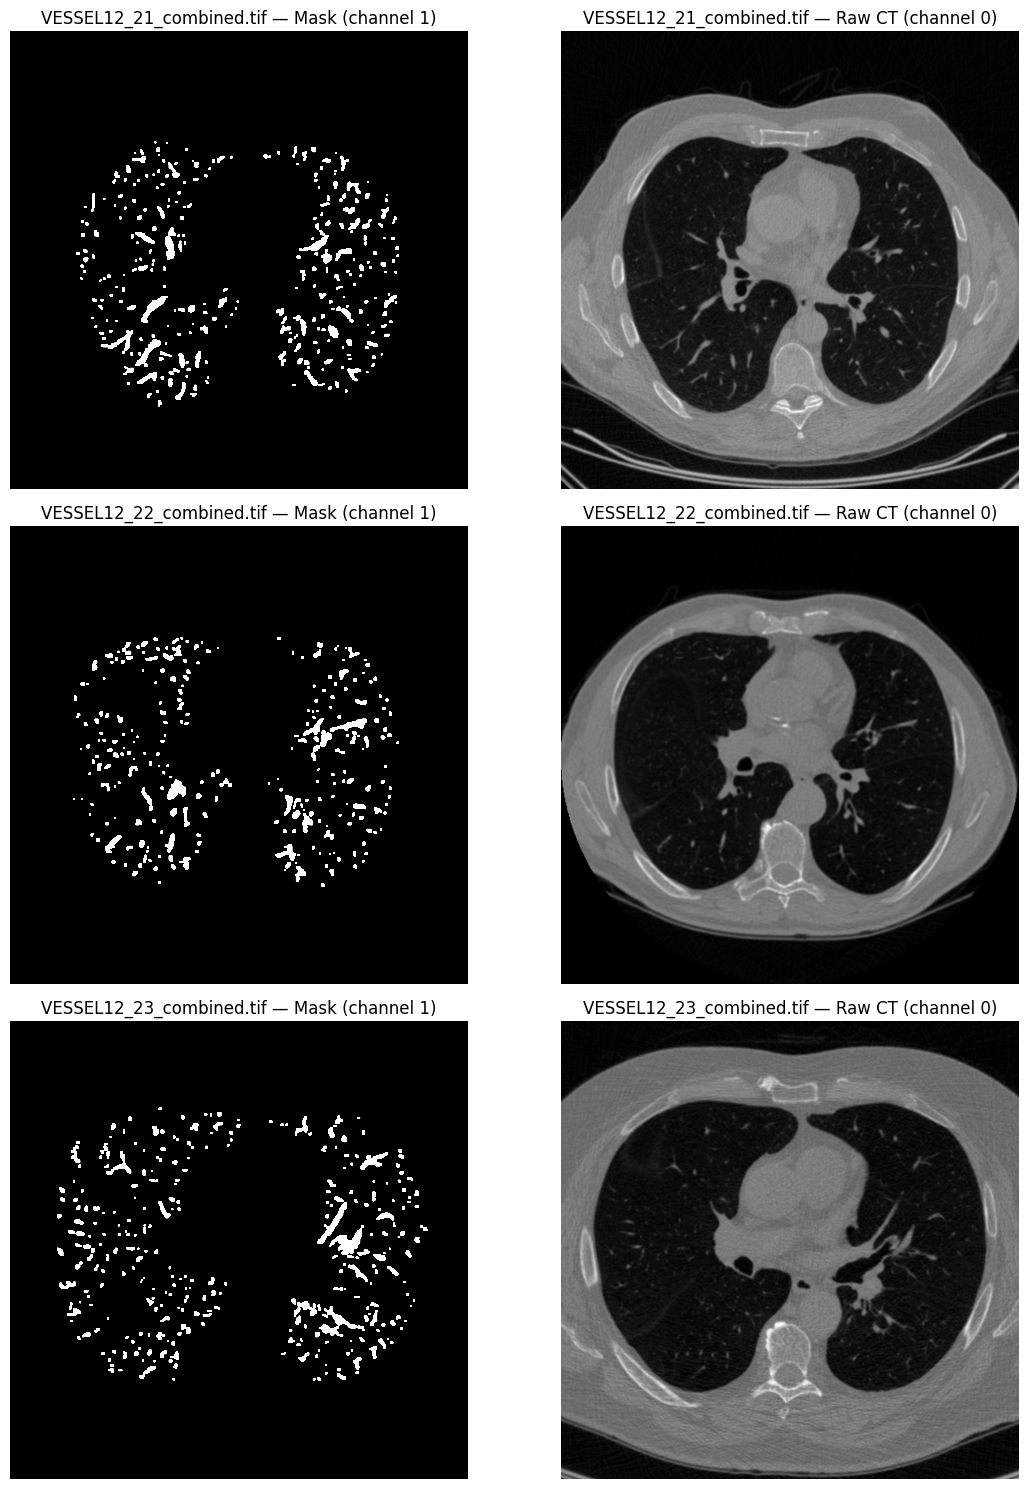

In [15]:
# %% [markdown]
# # Block 2 (Fixed): Visualize Mask & Raw Channels for Multiple Combined TIFs (Swapped)
#
# The mask and raw channels were reversed. Now channel 1 is treated as the mask,
# and channel 0 as the raw CT data.

# %%
import os
import tifffile as tiff
import matplotlib.pyplot as plt

# Base directory containing your combined TIFs
base_dir = '/media/home/DATA10TB/VESSEL12/FINAL'

# List of files to process
file_names = [
    'VESSEL12_21_combined.tif',
    'VESSEL12_22_combined.tif',
    'VESSEL12_23_combined.tif'
]

# Verify that each file exists
for fname in file_names:
    path = os.path.join(base_dir, fname)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File not found: {path}")

# Read all images
images = []
for fname in file_names:
    path = os.path.join(base_dir, fname)
    img = tiff.imread(path)
    if img.ndim != 4 or img.shape[3] != 2:
        raise ValueError(f"Expected a 4D image with 2 channels, got {img.shape} for {fname}")
    images.append((fname, img))

# Plotting
n = len(images)
fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n))

for i, (fname, img) in enumerate(images):
    z, y, x, c = img.shape
    print(f"{fname} dimensions (Z, Y, X, C): {z}, {y}, {x}, {c}")
    
    mid_idx = z // 2
    slice_img = img[mid_idx]  # shape (Y, X, 2)
    
    # Swap channels: channel 1 is mask, channel 0 is raw CT
    mask_slice = slice_img[:, :, 1]
    raw_slice  = slice_img[:, :, 0]
    
    ax_mask = axes[i, 0]
    ax_raw  = axes[i, 1]
    
    ax_mask.imshow(mask_slice, cmap='gray', vmin=0, vmax=1)
    ax_mask.set_title(f"{fname} — Mask (channel 1)")
    ax_mask.axis('off')
    
    ax_raw.imshow(raw_slice, cmap='gray')
    ax_raw.set_title(f"{fname} — Raw CT (channel 0)")
    ax_raw.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# %% [markdown]
# # Block 3 (Corrected): Pixel Validation with Thresholded Mask on Channel 1
#
# Assumes `annotation_dfs` (from Block 1) and `images` (from Block 2)
# are already in memory. This cell treats **channel 1** as the binary mask,
# thresholds it (≥1 → vessel), and computes per-volume and overall accuracy.

# %%
import numpy as np

# Initialize results containers
results_per_volume = {}
totals = {
    'points': 0,
    'matched': 0,
    'vessel': 0,
    'vessel_matched': 0,
    'non_vessel': 0,
    'non_vessel_matched': 0
}

# Loop over the already-loaded images
for fname, img in images:
    # Derive the case ID and lookup annotation DataFrame
    case_id = fname.split('_combined')[0]            # e.g. 'VESSEL12_21'
    ann_key = f"{case_id}_Annotations"               # e.g. 'VESSEL12_21_Annotations'
    df = annotation_dfs[ann_key]
    
    # Extract mask from channel 1 (not channel 0!) and threshold it
    # channel 0 is raw CT, channel 1 is the vessel mask
    mask_raw = img[:, :, :, 1]                       # shape (Z, Y, X)
    mask_bin = (mask_raw >= 1).astype(np.uint8)      # ≥1 → vessel (1), else non-vessel (0)
    
    # Coordinates & true labels
    zs = df['z'].values
    ys = df['y'].values
    xs = df['x'].values
    true_labels = df['label'].values
    
    # Sample thresholded mask at annotation points
    pred_labels = mask_bin[zs, ys, xs]
    matches = (pred_labels == true_labels)
    
    # Compute counts for this volume
    n_pts       = len(true_labels)
    n_match     = int(matches.sum())
    n_vess      = int((true_labels == 1).sum())
    n_non       = int((true_labels == 0).sum())
    n_vess_mat  = int((pred_labels[true_labels == 1] == 1).sum())
    n_non_mat   = int((pred_labels[true_labels == 0] == 0).sum())
    
    # Store per-volume stats
    results_per_volume[case_id] = {
        'total_points': n_pts,
        'matched': n_match,
        'vessel': n_vess,
        'vessel_matched': n_vess_mat,
        'non_vessel': n_non,
        'non_vessel_matched': n_non_mat
    }
    
    # Accumulate overall totals
    totals['points']             += n_pts
    totals['matched']            += n_match
    totals['vessel']             += n_vess
    totals['vessel_matched']     += n_vess_mat
    totals['non_vessel']         += n_non
    totals['non_vessel_matched'] += n_non_mat

# Print per-volume results
for case_id, stats in results_per_volume.items():
    acc = stats['matched'] / stats['total_points']
    print(f"{case_id}:")
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Total points: {stats['total_points']}")
    print(f"  Matched: {stats['matched']}")
    print(f"    Vessel matched: {stats['vessel_matched']} of {stats['vessel']}")
    print(f"    Non-vessel matched: {stats['non_vessel_matched']} of {stats['non_vessel']}")
    print()

# Print overall metrics
overall_acc      = totals['matched'] / totals['points']
overall_vess_acc = totals['vessel_matched'] / totals['vessel'] if totals['vessel'] else 0
overall_non_acc  = totals['non_vessel_matched'] / totals['non_vessel'] if totals['non_vessel'] else 0

print("Overall across all volumes:")
print(f"  Overall accuracy: {overall_acc:.2%}")
print(f"  Total points: {totals['points']}")
print(f"  Matched: {totals['matched']}")
print(f"    Vessel matched: {totals['vessel_matched']} of {totals['vessel']} ({overall_vess_acc:.2%})")
print(f"    Non-vessel matched: {totals['non_vessel_matched']} of {totals['non_vessel']} ({overall_non_acc:.2%})")

VESSEL12_21:
  Accuracy: 98.19%
  Total points: 277
  Matched: 272
    Vessel matched: 75 of 78
    Non-vessel matched: 197 of 199

VESSEL12_22:
  Accuracy: 96.90%
  Total points: 290
  Matched: 281
    Vessel matched: 90 of 98
    Non-vessel matched: 191 of 192

VESSEL12_23:
  Accuracy: 97.78%
  Total points: 315
  Matched: 308
    Vessel matched: 99 of 105
    Non-vessel matched: 209 of 210

Overall across all volumes:
  Overall accuracy: 97.62%
  Total points: 882
  Matched: 861
    Vessel matched: 264 of 281 (93.95%)
    Non-vessel matched: 597 of 601 (99.33%)
